# Analytical Questions

In [1]:
import pyspark.sql.functions as F
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.window import Window

from src.spark_session import get_spark
from src.utils.display_mimic import display

spark = get_spark()

:: loading settings :: url = jar:file:/opt/spark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /root/.ivy2/cache
The jars for the packages stored in: /root/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-19eb30f0-eceb-43f6-a77a-6966fb55d990;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.0.0 in central
	found io.delta#delta-storage;3.0.0 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
downloading https://repo1.maven.org/maven2/io/delta/delta-spark_2.12/3.0.0/delta-spark_2.12-3.0.0.jar ...
	[SUCCESSFUL ] io.delta#delta-spark_2.12;3.0.0!delta-spark_2.12.jar (682ms)
downloading https://repo1.maven.org/maven2/io/delta/delta-storage/3.0.0/delta-storage-3.0.0.jar ...
	[SUCCESSFUL ] io.delta#delta-storage;3.0.0!delta-storage.jar (55ms)
downloading https://repo1.maven.org/maven2/org/antlr/antlr4-runtime/4.9.3/antlr4-runtime-4.9.3.jar ...
	[SUCCESSFUL ] org.antlr#antlr4-runtime;4.9.3!antlr4-runtime.jar (95ms)
:: resolution report :: resolve 4177ms :: artifacts dl 84

## Which color generated the highest revenue each year?

In [12]:
orders_df = spark.table("publish.publish_orders")
products_df = spark.table("publish.publish_products")

In [3]:
df = (
    orders_df
    .join(
        products_df.select("ProductID", "Color"),
        "ProductID",
        "left"
    )
)

df = df.withColumn(
    "year",
    F.year("OrderDate")
)

In [4]:
revenue_by_color = (
    df.groupBy("year", "Color")
    .agg(
        F.sum("TotalLineExtendedPrice").alias("Revenue")
    )
)

In [13]:
window = Window.partitionBy("year").orderBy(F.desc("Revenue"))

top_color_per_year = (
    revenue_by_color
    .withColumn("rank", F.row_number().over(window))
    .filter(F.col("rank") == 1)
    .drop("rank")
)

display(top_color_per_year)

,year,Color,Revenue
0,2021,Red,6019613.1500
1,2022,Black,14005216.1900
2,2023,Black,15047626.4300
3,2024,Yellow,6368141.4900


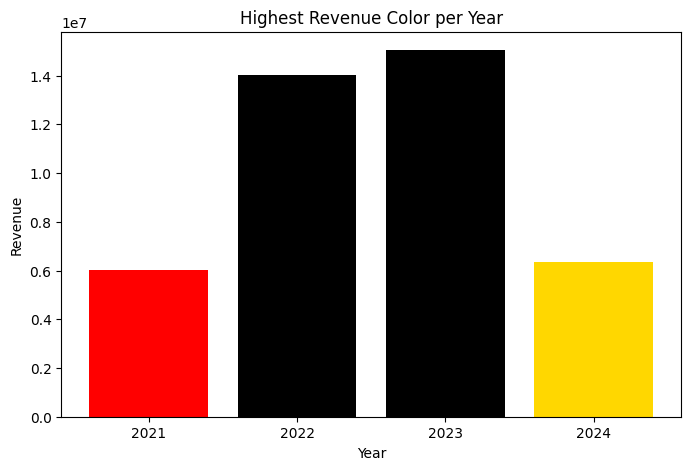

In [6]:
pdf = top_color_per_year.toPandas()

pdf["year"] = pdf["year"].astype(int)

pdf = pdf.sort_values("year")

color_map = {
    "Red": "red",
    "Black": "black",
    "Yellow": "gold",
    "Blue": "blue",
    "Silver": "silver",
    "Multi": "purple",
    "N/A": "gray"
}

colors = pdf["Color"].map(color_map)

plt.figure(figsize=(8,5))

plt.bar(
    pdf["year"],
    pdf["Revenue"],
    color=colors
)

plt.title("Highest Revenue Color per Year")
plt.xlabel("Year")
plt.ylabel("Revenue")

plt.xticks(pdf["year"])

plt.show()

Black products generated the highest revenue in most years.

## What is the average LeadTimeInBusinessDays by ProductCategoryName?

In [7]:
df = (
    orders_df
    .join(
        products_df.select("ProductID", "ProductCategoryName"),
        "ProductID",
        "left"
    )
)

In [8]:
avg_leadtime = (
    df.groupBy("ProductCategoryName")
    .agg(
        F.avg("LeadTimeInBusinessDays")
        .alias("AvgLeadTime")
    )
)

display(avg_leadtime)

,ProductCategoryName,AvgLeadTime
0,Bikes,5.667898
1,None,5.720208
2,Clothing,5.709380
3,Accessories,5.702788
4,Components,5.667114


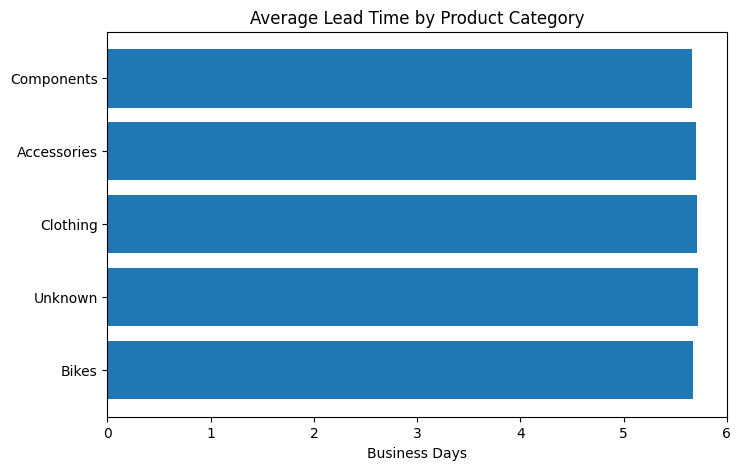

In [11]:
pdf_lead = avg_leadtime.toPandas()

pdf_lead["ProductCategoryName"] = pdf_lead["ProductCategoryName"].fillna("Unknown")

plt.figure(figsize=(8,5))

plt.barh(
    pdf_lead["ProductCategoryName"],
    pdf_lead["AvgLeadTime"]
)

plt.title("Average Lead Time by Product Category")
plt.xlabel("Business Days")

plt.show()

The average lead time across product categories is very similar, ranging from approximately 5.66 to 5.72 business days.

This indicates a fairly consistent fulfillment process across product categories, suggesting a standardized logistics pipeline.

In [17]:
display(spark.sql('SELECT DISTINCT ProductSubCategoryName FROM publish.publish_products WHERE ProductCategoryName IS NULL'))

,ProductSubCategoryName
0,Bottom Brackets
1,Derailleurs
2,Chains
3,Hydration Packs
4,Bottles and Cages
5,Forks
6,Brakes
7,Panniers
8,Bike Racks
9,Fenders
